# TTT-Dialect: AI Hub 방언 음성 인식

**시작 전 필수:** 런타임 → 런타임 유형 변경 → **T4 GPU** 선택

---
**데이터 업로드 방법 (시작 전 1회만)**
1. 탐색기에서 `C:\Users\kts64\TTT\data\upload_ready\dialect` 폴더 열기
2. 전체 선택 → [drive.google.com](https://drive.google.com) 에서 `TTT-data` 폴더 만들고 업로드
3. 업로드 완료 후 아래 Step 1부터 실행

## Step 1 — Drive 연동

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

# Drive에서 데이터 폴더 찾기
DATA_DIR = '/content/drive/MyDrive/TTT-data'

if not os.path.exists(DATA_DIR):
    print('TTT-data 폴더를 찾지 못했습니다. Drive 루트 목록:')
    for item in os.listdir('/content/drive/MyDrive'):
        print(f'  {item}')
else:
    wav_cnt  = sum(1 for f in os.listdir(DATA_DIR) if f.endswith('.wav'))
    json_cnt = sum(1 for f in os.listdir(DATA_DIR) if f.endswith('.json'))
    print(f'Drive 연동 완료!')
    print(f'  wav: {wav_cnt}개 / json: {json_cnt}개')
    print(f'  경로: {DATA_DIR}')

Mounted at /content/drive
Drive 연동 완료!
  wav: 1000개 / json: 1000개
  경로: /content/drive/MyDrive/TTT-data


## Step 2 — 패키지 설치 및 코드 클론

In [2]:
import os

REPO_DIR = '/content/TTT-Dialect'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/kts6450/TTT-Dialect.git {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}
!pip install -q openai-whisper transformers librosa soundfile jiwer loguru pyyaml accelerate torchaudio
print('done!')

Cloning into '/content/TTT-Dialect'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 90 (delta 24), reused 82 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 77.39 KiB | 1.68 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/TTT-Dialect
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 99.1 MB/s eta 0:00:00
done!


## Step 3 — GPU 확인 및 모델 로드

In [3]:
import sys, torch
sys.path.insert(0, '/content/TTT-Dialect')

print(f'GPU: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

from models.base_whisper import KoreanWhisperModel
MODEL_NAME = 'SungBeom/whisper-small-ko'
print(f'모델 로드: {MODEL_NAME}')
model = KoreanWhisperModel(MODEL_NAME)
model.model = model.model.to(DEVICE)
params = model.count_parameters()
print(f'완료! 파라미터: {params["total"]:,}')

GPU: True
  Tesla T4


2026-04-04 05:43:53.236 | INFO     | models.base_whisper:__init__:27 - 모델 로드 중: SungBeom/whisper-small-ko


모델 로드: SungBeom/whisper-small-ko


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

완료! 파라미터: 241,734,912


## Step 4 — manifest 생성 (AI Hub 방언 데이터)

In [4]:
import json, os, librosa
from tqdm.notebook import tqdm

SR = 16000
manifest = []

PROVINCE_MAP = {
    'gs': '경상', 'gw': '강원', 'jl': '전라',
    'cc': '충청', 'jj': '제주', 'se': '서울'
}

def parse_label(json_path):
    """방언 데이터 json 파싱 (sentences[].standard 합치기)"""
    with open(json_path, encoding='utf-8') as jf:
        d = json.load(jf)

    trans = d.get('transcription', {})

    # 방법1: 전체 standard 필드
    text = trans.get('standard', '').strip()

    # 방법2: sentences 리스트 합치기
    if not text:
        sentences = trans.get('sentences', [])
        text = ' '.join(
            s.get('standard', '') or s.get('dialect', '')
            for s in sentences
        ).strip()

    # 방언 코드
    speakers = d.get('speaker', [{}])
    province_code = speakers[0].get('residenceProvince', 'gs') if speakers else 'gs'
    dialect = PROVINCE_MAP.get(province_code, province_code)

    # 나이
    birth_year = speakers[0].get('birthYear', 1960) if speakers else 1960
    try:
        age = 2024 - int(birth_year)
    except:
        age = 65

    return text, dialect, age

files = os.listdir(DATA_DIR)
wav_files  = [f for f in files if f.endswith('.wav')]
json_stems = {os.path.splitext(f)[0] for f in files if f.endswith('.json')}

print(f'처리 중: wav {len(wav_files)}개')
added, skip = 0, 0

for wav_fname in tqdm(wav_files):
    try:
        stem = os.path.splitext(wav_fname)[0]
        if stem not in json_stems:
            skip += 1
            continue

        json_path = os.path.join(DATA_DIR, stem + '.json')
        wav_path  = os.path.join(DATA_DIR, wav_fname)

        text, dialect, age = parse_label(json_path)
        if not text:
            skip += 1
            continue

        audio = librosa.load(wav_path, sr=SR)[0]
        duration = len(audio) / SR
        if duration < 0.5 or duration > 60:
            skip += 1
            continue

        manifest.append({
            'audio_path': wav_path,
            'transcript': text,
            'dialect': dialect,
            'speaker_age': age,
            'speaker_id': stem[:12],
            'duration_sec': round(duration, 2),
            'type': 'dialect'
        })
        added += 1
    except Exception as e:
        skip += 1

MANIFEST_PATH = '/content/manifest.jsonl'
with open(MANIFEST_PATH, 'w', encoding='utf-8') as f:
    for m in manifest:
        f.write(json.dumps(m, ensure_ascii=False) + '\n')

print(f'added: {added} / skipped: {skip}')
if manifest:
    print(f'예시: "{manifest[0]["transcript"][:50]}"')
    print(f'방언: {manifest[0]["dialect"]} | 나이: {manifest[0]["speaker_age"]}')
else:
    print('0개 — 아래 진단 셀 실행')

처리 중: wav 1000개


  0%|          | 0/1000 [00:00<?, ?it/s]

added: 994 / skipped: 6
예시: "매운 음식을 저는 좋아하지 않습니다 고추나 이런 거 매운 거 먹으면 속이 아프기 떠래 어느"
방언: 강원 | 나이: 84


## Step 4-진단 (manifest가 0개일 때만 실행)

In [5]:
import json, os
for f in os.listdir(DATA_DIR):
    if f.endswith('.json'):
        with open(os.path.join(DATA_DIR, f), encoding='utf-8') as jf:
            d = json.load(jf)
        print('keys:', list(d.keys()))
        trans = d.get('transcription', {})
        print('transcription keys:', list(trans.keys()))
        print('standard:', str(trans.get('standard', ''))[:100])
        sents = trans.get('sentences', [])
        if sents:
            print('sentences[0] keys:', list(sents[0].keys()))
            print('sentences[0].standard:', sents[0].get('standard', ''))
        break

keys: ['fileName', 'speaker', 'collector', 'script', 'audio', 'transcription', 'annotation', 'stt']
transcription keys: ['segments', 'sentences', 'dialect', 'pronunciation', 'standard']
standard: 저희 아버지는 육이오 때 돌아가셨어요 어머니 혼자서 서른다섯에 혼자 돼 가지고 우리 삼남매를 길렀거든 어머니가 고생을 많이 했지 우리 어머니가 팔십팔 에 돌아가셨는데 그거 했었어 
sentences[0] keys: ['speakerId', 'intonations', 'startTime', 'endTime', 'dialect', 'pronunciation', 'standard', 'sentenceId']
sentences[0].standard: 저희 아버지는 육이오 때 돌아가셨어요


## Step 5 — TTT 어댑터 초기화

In [6]:
from models.ttt_adapter import TTTAdapter

adapter = TTTAdapter(
    base_model=model,
    profile_dir='/content/user_profiles',
    top_k_layers=2,
    lr=1e-4,
    adaptation_steps=30,
)
print('TTT adapter ready!')

TTT adapter ready!


## Step 6 — TTT 이전 WER 측정

In [7]:
import json, librosa, torch
from jiwer import wer
from tqdm.notebook import tqdm

SR = 16000
N_TEST = 50

samples = []
with open(MANIFEST_PATH) as f:
    for line in f:
        samples.append(json.loads(line))

print(f'전체: {len(samples)}개')
if len(samples) == 0:
    raise SystemExit('manifest 비어있음 — Step 4 재실행 필요')

test_samples = samples[:N_TEST]

def infer(sample, mdl):
    audio, _ = librosa.load(sample['audio_path'], sr=SR)
    feat = mdl.processor.feature_extractor(
        audio, sampling_rate=SR, return_tensors='pt'
    ).input_features.to(DEVICE)
    with torch.no_grad():
        result = mdl.transcribe(feat)
    return result[0] if result else ''

print(f'TTT 이전 WER 측정 ({N_TEST}개)...')
refs, hyps = [], []
for s in tqdm(test_samples):
    refs.append(s['transcript'])
    hyps.append(infer(s, model))

wer_before = wer(refs, hyps)
print(f'TTT 이전 WER: {wer_before:.1%}')
print(f'  정답: "{refs[0][:40]}"')
print(f'  인식: "{hyps[0][:40]}"')

전체: 994개
TTT 이전 WER 측정 (50개)...


  0%|          | 0/50 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformer

TTT 이전 WER: 33.4%
  정답: "매운 음식을 저는 좋아하지 않습니다 고추나 이런 거 매운 거 먹으면 속이"
  인식: "매운 음식을 저는 좋아하지 않습니다 고추나 이런 거 매운 거 먹으면 속이"


## Step 7 — TTT 캘리브레이션 (핵심)

In [8]:
N_CALIB = 20
calib_samples = samples[N_TEST:N_TEST + N_CALIB]

calib_features, calib_texts = [], []
for s in calib_samples:
    audio, _ = librosa.load(s['audio_path'], sr=SR)
    feat = model.processor.feature_extractor(
        audio, sampling_rate=SR, return_tensors='pt'
    ).input_features[0]
    calib_features.append(feat)
    calib_texts.append(s['transcript'])

print(f'TTT 캘리브레이션: {N_CALIB}개 (약 1~2분)')

profile = adapter.calibrate(
    user_id='aihub_dialect_user',
    audio_features=calib_features,
    transcripts=calib_texts,
    dialect=calib_samples[0].get('dialect', '경상'),
    age=calib_samples[0].get('speaker_age', 65),
)

print(f'TTT 완료!')
print(f'  WER 이전: {profile.wer_before:.1%}')
print(f'  WER 이후: {profile.wer_after:.1%}')
print(f'  개선:     {profile.wer_before - profile.wer_after:.1%}p')

2026-04-04 05:46:53.093 | INFO     | models.ttt_adapter:calibrate:164 - [aihub_dialect_user] 캘리브레이션 시작: 20개 문장
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TTT 캘리브레이션: 20개 (약 1~2분)


Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TTT 완료!
  WER 이전: 32.7%
  WER 이후: 23.1%
  개선:     9.7%p


## Step 8 — 결과 시각화 및 Drive 저장

## Step 9 — Ablation: WER vs Calibration Sample Count (paper figure)

In [ ]:
import json, librosa, torch, copy, os
import matplotlib.pyplot as plt
from jiwer import wer as calc_wer
from tqdm.notebook import tqdm

SR = 16000
N_TEST = 50
CALIB_COUNTS = [0, 5, 10, 20, 50]
TOP_K_LAYERS = 2
LR = 1e-4
ADAPT_STEPS = 30

results = []
test_samples = samples[:N_TEST]   # 테스트용 50개 (항상 고정)
pool_samples = samples[N_TEST:]   # 캘리브레이션 풀

def infer_batch(sample_list, mdl):
    refs, hyps = [], []
    for s in sample_list:
        audio, _ = librosa.load(s['audio_path'], sr=SR)
        feat = mdl.processor.feature_extractor(
            audio, sampling_rate=SR, return_tensors='pt'
        ).input_features.to(DEVICE)
        with torch.no_grad():
            out = mdl.transcribe(feat)
        refs.append(s['transcript'])
        hyps.append(out[0] if out else '')
    return calc_wer(refs, hyps)

def run_ttt_direct(mdl, calib_s, calib_texts):
    """
    TTTAdapter 를 거치지 않고 fresh_model 을 직접 학습
    (TTTAdapter 는 내부에서 clone 을 만들어 학습하므로
     fresh_model 자체가 업데이트되지 않는 문제를 우회)
    """
    # 상위 2개 레이어만 언프리즈
    mdl.unfreeze_encoder_top_k(k=TOP_K_LAYERS)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, mdl.parameters()),
        lr=LR, weight_decay=0.01
    )
    for step in range(ADAPT_STEPS):
        idx = step % len(calib_s)
        feat = calib_s[idx].unsqueeze(0).to(DEVICE)
        label_ids = mdl.processor.tokenizer(
            calib_texts[idx], return_tensors='pt'
        ).input_ids.to(DEVICE)
        optimizer.zero_grad()
        loss = mdl(input_features=feat, labels=label_ids).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, mdl.parameters()), 1.0
        )
        optimizer.step()

print('Measuring WER for each calibration count...')
print('(~5-10 min)\n')

for n_calib in CALIB_COUNTS:
    print(f'[n_calib={n_calib}] ', end='', flush=True)

    # 매 실험마다 원본 모델 복사 (독립 실험 보장)
    fresh_model = copy.deepcopy(model)
    fresh_model.model = fresh_model.model.to(DEVICE)

    if n_calib == 0:
        wer_val = infer_batch(test_samples, fresh_model)
        print(f'WER={wer_val:.1%} (baseline)')
    else:
        calib_s = pool_samples[:n_calib]

        # 오디오 특징 추출
        feats, texts = [], []
        for s in calib_s:
            audio, _ = librosa.load(s['audio_path'], sr=SR)
            feat = fresh_model.processor.feature_extractor(
                audio, sampling_rate=SR, return_tensors='pt'
            ).input_features[0]
            feats.append(feat)
            texts.append(s['transcript'])

        # fresh_model 을 직접 업데이트 (clone 없이)
        run_ttt_direct(fresh_model, feats, texts)

        # 고정 테스트 50개로 WER 측정
        wer_val = infer_batch(test_samples, fresh_model)
        print(f'WER={wer_val:.1%}')

    results.append({'n_calib': n_calib, 'wer': wer_val})

# 결과 요약
print('\n=== Results ===')
baseline_wer = results[0]['wer']
for r in results:
    tag = '(baseline)' if r['n_calib'] == 0 else f"(improvement: {(baseline_wer - r['wer'])*100:.1f}pp)"
    print(f"  n={r['n_calib']:2d}: WER {r['wer']:.1%}  {tag}")

# 그래프
fig, ax = plt.subplots(figsize=(9, 5))
ns   = [r['n_calib'] for r in results]
wers = [r['wer'] * 100 for r in results]

ax.plot(ns, wers, 'o-', color='#667eea', linewidth=2.5, markersize=10, zorder=3)
ax.fill_between(ns, wers, alpha=0.12, color='#667eea')

for n, w in zip(ns, wers):
    ax.annotate(f'{w:.1f}%', (n, w), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=baseline_wer * 100, color='#FF6B6B', linestyle='--',
           linewidth=1.5, label=f'Baseline (no TTT): {baseline_wer:.1%}')
ax.set_xlabel('Number of calibration samples', fontsize=12)
ax.set_ylabel('WER (%) - lower is better', fontsize=12)
ax.set_title('WER vs Calibration Sample Count', fontsize=14, fontweight='bold')
ax.set_xticks(ns)
ax.set_xticklabels([str(n) if n > 0 else '0\n(baseline)' for n in ns])
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

RESULT_DIR = '/content/drive/MyDrive/TTT-results'
os.makedirs(RESULT_DIR, exist_ok=True)
plt.savefig(f'{RESULT_DIR}/calib_count_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

with open(f'{RESULT_DIR}/calib_count_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved: {RESULT_DIR}/calib_count_analysis.png')

/tmp/ipykernel_1335/1015598920.py:29: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1335/1015598920.py:29: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1335/1015598920.py:29: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1335/1015598920.py:29: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1335/1015598920.py:29: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1335/1015598920.py:29: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1335/1015598920.py:29: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

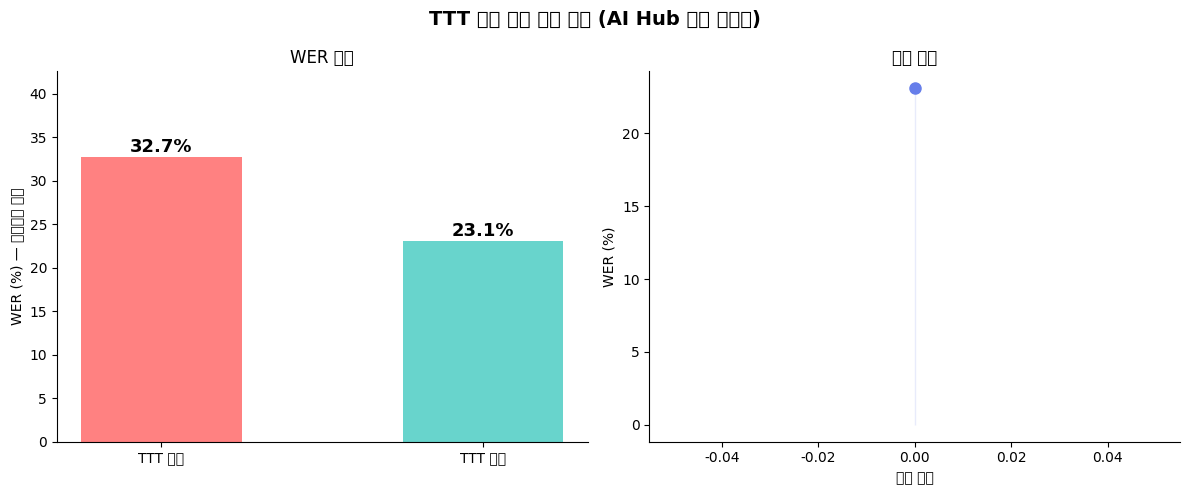

TTT 이전 WER: 32.7%
TTT 이후 WER: 23.1%
개선: 9.7%p (29.5%)
결과 저장: /content/drive/MyDrive/TTT-results


In [9]:
import matplotlib.pyplot as plt, json, os
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('TTT 적용 전후 성능 비교 (AI Hub 방언 데이터)', fontsize=14, fontweight='bold')

ax = axes[0]
values = [profile.wer_before * 100, profile.wer_after * 100]
bars = ax.bar(['TTT 이전', 'TTT 이후'], values, color=['#FF6B6B', '#4ECDC4'], alpha=0.85, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('WER (%) — 낮을수록 좋음')
ax.set_title('WER 비교')
ax.set_ylim(0, max(values) * 1.3)
ax.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
if profile.adaptation_history:
    steps = list(range(len(profile.adaptation_history)))
    wers = [h['wer'] * 100 for h in profile.adaptation_history]
    ax2.plot(steps, wers, 'o-', color='#667eea', linewidth=2.5, markersize=8)
    ax2.fill_between(steps, wers, alpha=0.15, color='#667eea')
    ax2.set_xlabel('적응 횟수')
    ax2.set_ylabel('WER (%)')
    ax2.set_title('적응 이력')
    ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

RESULT_DIR = '/content/drive/MyDrive/TTT-results'
os.makedirs(RESULT_DIR, exist_ok=True)
plt.savefig(f'{RESULT_DIR}/wer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

summary = {
    'model': MODEL_NAME,
    'data': 'AI Hub 방언 (경상+강원)',
    'n_test': N_TEST, 'n_calib': N_CALIB,
    'wer_before': profile.wer_before,
    'wer_after': profile.wer_after,
    'improvement_pp': profile.wer_before - profile.wer_after,
    'improvement_pct': (profile.wer_before - profile.wer_after) / max(profile.wer_before, 1e-9) * 100
}
with open(f'{RESULT_DIR}/summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f'TTT 이전 WER: {summary["wer_before"]:.1%}')
print(f'TTT 이후 WER: {summary["wer_after"]:.1%}')
print(f'개선: {summary["improvement_pp"]:.1%}p ({summary["improvement_pct"]:.1f}%)')
print(f'결과 저장: {RESULT_DIR}')